In [1]:
import pandas as pd                                # Import required Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df:pd.DataFrame=pd.read_csv(r"C:\Users\fa440\Downloads\csv files (Data sets)\Loan_prediction_default.csv") # import dataset using pandas

In [3]:
df.shape        # to identify the dimensions of data structures like arrays and tables (e.g. (rows, columns)

(255347, 18)

In [4]:
df.columns                      # Check Columns name

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [5]:
df.head()                 # Check data (well-structured or not)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [6]:
df.info()             # dataset information

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [7]:
                                   # Handle missing data appropriately
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
                                   # Fill numerical missing values with mean
numerical_columns = df.select_dtypes(include=np.number).columns
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

                                 # Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_columns:
    if not df[col].mode().empty:                                # Prevents crash if column is all NaN
        df[col] = df[col].fillna(df[col].mode()[0])

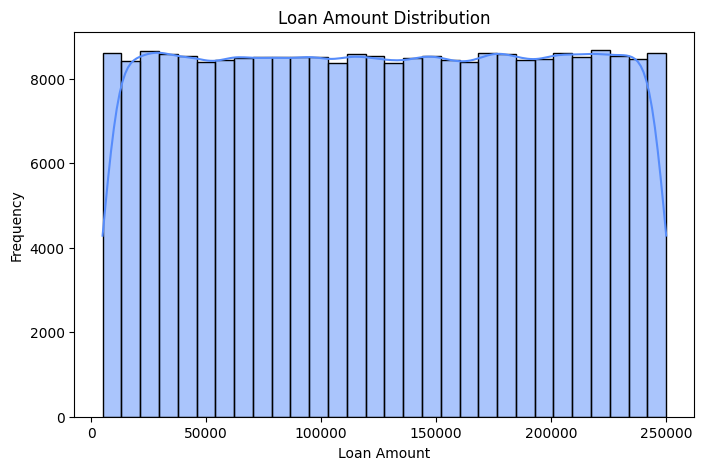

In [9]:
                                     # Data Visualization
  # 1-Loan Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['LoanAmount'], bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

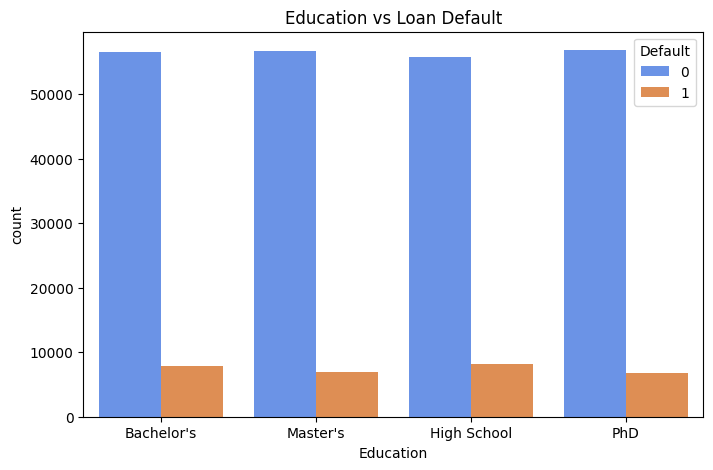

In [10]:
  # [ 2-Education vs Default]
plt.figure(figsize=(8,5))

sns.countplot(x='Education', hue='Default', data=df)
plt.title("Education vs Loan Default")
plt.show()

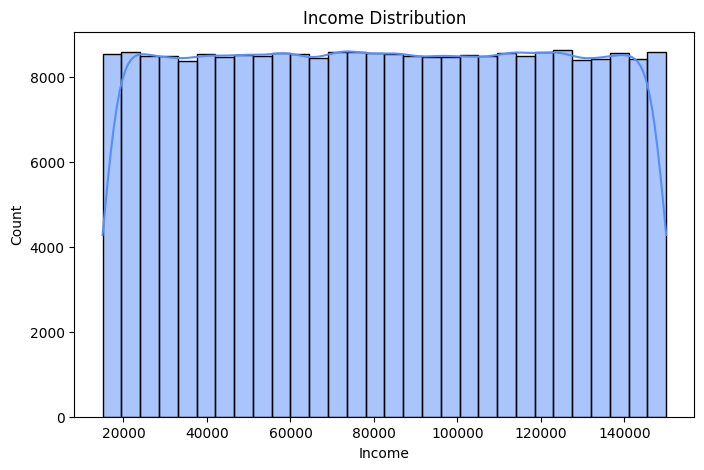

In [11]:
     # 3-Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=30, kde=True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.show()

In [12]:
# Transform data to make model like Logistic regression which doesn't  work with text data
label_encoder = LabelEncoder()              # Convert Categorical Columns into Numerical

categorical_columns = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [13]:
#Define Features and Target

df = df.drop('LoanID', axis=1)                     # Remove LoanID column

X = df.drop('Default', axis=1)                            #Features and Target
y = df['Default']

In [14]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
                                      # Training Model using Decision Tree
from sklearn.tree import DecisionTreeClassifier         #Import Decision Tree

model = DecisionTreeClassifier(random_state=42)        #  Model Training
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [16]:
   # Make Predictions
y_pred = model.predict(X_test)

In [18]:
        #Evaluate Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8026042686508713
Accuracy: 0.8026042686508713


In [20]:
      #Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[39623  5547]
 [ 4534  1366]]
[[39623  5547]
 [ 4534  1366]]


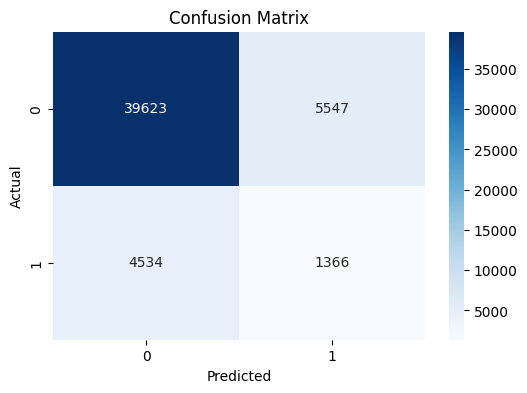

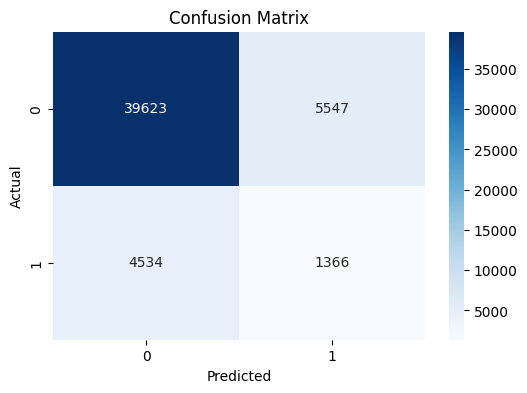

In [22]:
   #Confusion Matrix Visualization
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
                                  # Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45170
           1       0.20      0.23      0.21      5900

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.82      0.80      0.81     51070

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45170
           1       0.20      0.23      0.21      5900

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.82      0.80      0.81     51070



In [26]:
print("""CONCLUSION :
1-The dataset was thoroughly cleaned and prepared for analysis. Missing values were handled appropriately,
  duplicate records were removed, and categorical variables were encoded into numerical form.

2-Outliers and inconsistencies were also addressed to improve data quality. After preprocessing,the
  dataset became structured and suitable for machine learning model training, ensuring better accuracy
  and reliability.
""")

CONCLUSION :
1-The dataset was thoroughly cleaned and prepared for analysis. Missing values were handled appropriately,
  duplicate records were removed, and categorical variables were encoded into numerical form.

2-Outliers and inconsistencies were also addressed to improve data quality. After preprocessing,the
  dataset became structured and suitable for machine learning model training, ensuring better accuracy
  and reliability.

CONCLUSION :
1-The dataset was thoroughly cleaned and prepared for analysis. Missing values were handled appropriately,
  duplicate records were removed, and categorical variables were encoded into numerical form.

2-Outliers and inconsistencies were also addressed to improve data quality. After preprocessing,the
  dataset became structured and suitable for machine learning model training, ensuring better accuracy
  and reliability.

